In [1]:
!pip install yfinance pandas numpy openpyxl

In [2]:
# ==============================================================
# ACC102 Track 2 - Financial Data Extraction (Yahoo Finance)
# Purpose: Retrieve 2020-2024 annual financial indicators for 4 Chinese A-shares
# Target Tickers: 002353.SZ, 601061.SH, 002466.SZ, 601012.SH
# Data Source: Yahoo Finance (compliant & accessible, no WRDS required)
# ==============================================================

import yfinance as yf
import pandas as pd
import numpy as np

# Step 1: Define target tickers (Yahoo Finance format for Chinese A-shares)
tickers = [
    '002353.SZ',  # Jereh Group
    '601061.SS',  # CITIC Metal (SH -> SS in Yahoo Finance)
    '002466.SZ',  # Tianqi Lithium
    '601012.SS'   # LONGi Green Energy (SH -> SS in Yahoo Finance)
]

# Step 2: Create empty DataFrame to store financial data
financial_data = []

# Step 3: Extract annual financial indicators for each ticker
for ticker in tickers:
    # Download stock data from Yahoo Finance
    stock = yf.Ticker(ticker)
    
    # Get annual financial statements
    income_stmt = stock.financials.T  # Income statement (transposed for year rows)
    balance_sheet = stock.balance_sheet.T  # Balance sheet (transposed)
    
    # Filter data to 2020-2024
    years = [2020, 2021, 2022, 2023, 2024]
    income_stmt = income_stmt.loc[income_stmt.index.year.isin(years)]
    balance_sheet = balance_sheet.loc[balance_sheet.index.year.isin(years)]
    
    # Calculate core financial indicators
    for year in income_stmt.index.year:
        if year not in balance_sheet.index.year:
            continue
        
        # Get annual data
        inc = income_stmt.loc[income_stmt.index.year == year].iloc[0]
        bal = balance_sheet.loc[balance_sheet.index.year == year].iloc[0]
        
        # Calculate key indicators (handle missing values)
        gross_profit = inc.get('Gross Profit', 0)
        total_revenue = inc.get('Total Revenue', 1)  # Avoid division by zero
        gross_profit_margin = (gross_profit / total_revenue) * 100 if total_revenue != 0 else 0
        
        net_income = inc.get('Net Income', 0)
        net_profit_margin = (net_income / total_revenue) * 100 if total_revenue != 0 else 0
        
        shareholders_equity = bal.get('Total Equity', 1)
        roe = (net_income / shareholders_equity) * 100 if shareholders_equity != 0 else 0
        
        total_debt = bal.get('Total Debt', 0)
        total_assets = bal.get('Total Assets', 1)
        debt_ratio = (total_debt / total_assets) * 100 if total_assets != 0 else 0
        
        current_assets = bal.get('Current Assets', 0)
        current_liabilities = bal.get('Current Liabilities', 1)
        current_ratio = current_assets / current_liabilities if current_liabilities != 0 else 0
        
        # Get market indicators (PE/PB)
        pe = stock.info.get('trailingPE', 0)
        pb = stock.info.get('priceToBook', 0)
        
        # Append to list
        financial_data.append({
            'ticker': ticker.replace('.SS', '.SH'),  # Restore SH suffix
            'year': year,
            'gross_profit_margin': gross_profit_margin,
            'net_profit_margin': net_profit_margin,
            'roe': roe,
            'debt_ratio': debt_ratio,
            'current_ratio': current_ratio,
            'revenue': total_revenue,
            'net_income': net_income,
            'pe': pe,
            'pb': pb
        })

# Step 4: Convert to DataFrame and calculate growth rates
df = pd.DataFrame(financial_data)
df = df.sort_values(['ticker', 'year'])
df['revenue_growth'] = df.groupby('ticker')['revenue'].pct_change() * 100
df['ni_growth'] = df.groupby('ticker')['net_income'].pct_change() * 100

# Step 5: Data cleaning (fill missing values)
df = df.fillna(0)

# Step 6: Select final clean indicators
final_data = df[[
    'ticker', 'year',
    'gross_profit_margin', 'net_profit_margin', 'roe',
    'debt_ratio', 'current_ratio',
    'revenue_growth', 'ni_growth', 'pe', 'pb'
]].copy()

# Step 7: Verify and save data
print("✅ Data extraction successful! First 10 rows:")
print(final_data.head(10))

final_data.to_excel('yahoo_4stocks_2020_2024_clean.xlsx', index=False)
print("\n✅ Clean data saved to: yahoo_4stocks_2020_2024_clean.xlsx")
print("\n✅ Ready for data cleaning/visualization!")

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_38600\663395035.py:87: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['revenue_growth'] = df.groupby('ticker')['revenue'].pct_change() * 100
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_38600\663395035.py:88: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['ni_growth'] = df.groupby('ticker')['net_income'].pct_change() * 100


✅ Data extraction successful! First 10 rows:
       ticker  year  gross_profit_margin  net_profit_margin           roe  \
2   002353.SZ  2022            33.231709          19.676985  2.244950e+11   
1   002353.SZ  2023            32.751978          17.642044  2.454378e+11   
0   002353.SZ  2024            33.696089          19.670917  2.627035e+11   
9   002466.SZ  2021             0.000000           0.000000  0.000000e+00   
8   002466.SZ  2022            85.123878          59.642162  2.412459e+12   
7   002466.SZ  2023            84.985206          18.016522  7.297315e+11   
6   002466.SZ  2024            46.074378         -60.509008 -7.904580e+11   
13  601012.SH  2021            20.216739          11.271704  9.085881e+11   
12  601012.SH  2022            15.375432          11.482011  1.481158e+12   
11  601012.SH  2023            18.537271           8.302408  1.075143e+12   

    debt_ratio  current_ratio  revenue_growth   ni_growth          pe  \
2     8.025764       2.165887     

✅ Loaded raw data shape: (14, 11)
✅ Available columns in data: ['ticker', 'year', 'gross_profit_margin', 'net_profit_margin', 'roe', 'debt_ratio', 'current_ratio', 'revenue_growth', 'ni_growth', 'pe', 'pb']
✅ Data cleaning completed! Cleaned data shape: (14, 11)
✅ Trend charts saved as: financial_trend_charts.png
✅ Comparison chart saved as: cross_company_comparison.png

✅ Comprehensive Investment Score (Average of Available Years):
      ticker  profit_score  risk_score  growth_score  total_score
0  002353.SZ          2.02        3.00          3.00         8.02
1  601012.SH          2.15        1.96          2.17         6.28
2  002466.SZ          2.75        2.77          0.00         5.52
3  601061.SH          0.00        0.00          2.69         2.69

✅ Investment Portfolio Strategy (100,000 RMB Principal):
      ticker  total_score  weight  investment_amount
0  002353.SZ         8.02  36.00%           35626.47
1  601012.SH         6.28  28.00%           27908.40
2  002466.SZ    

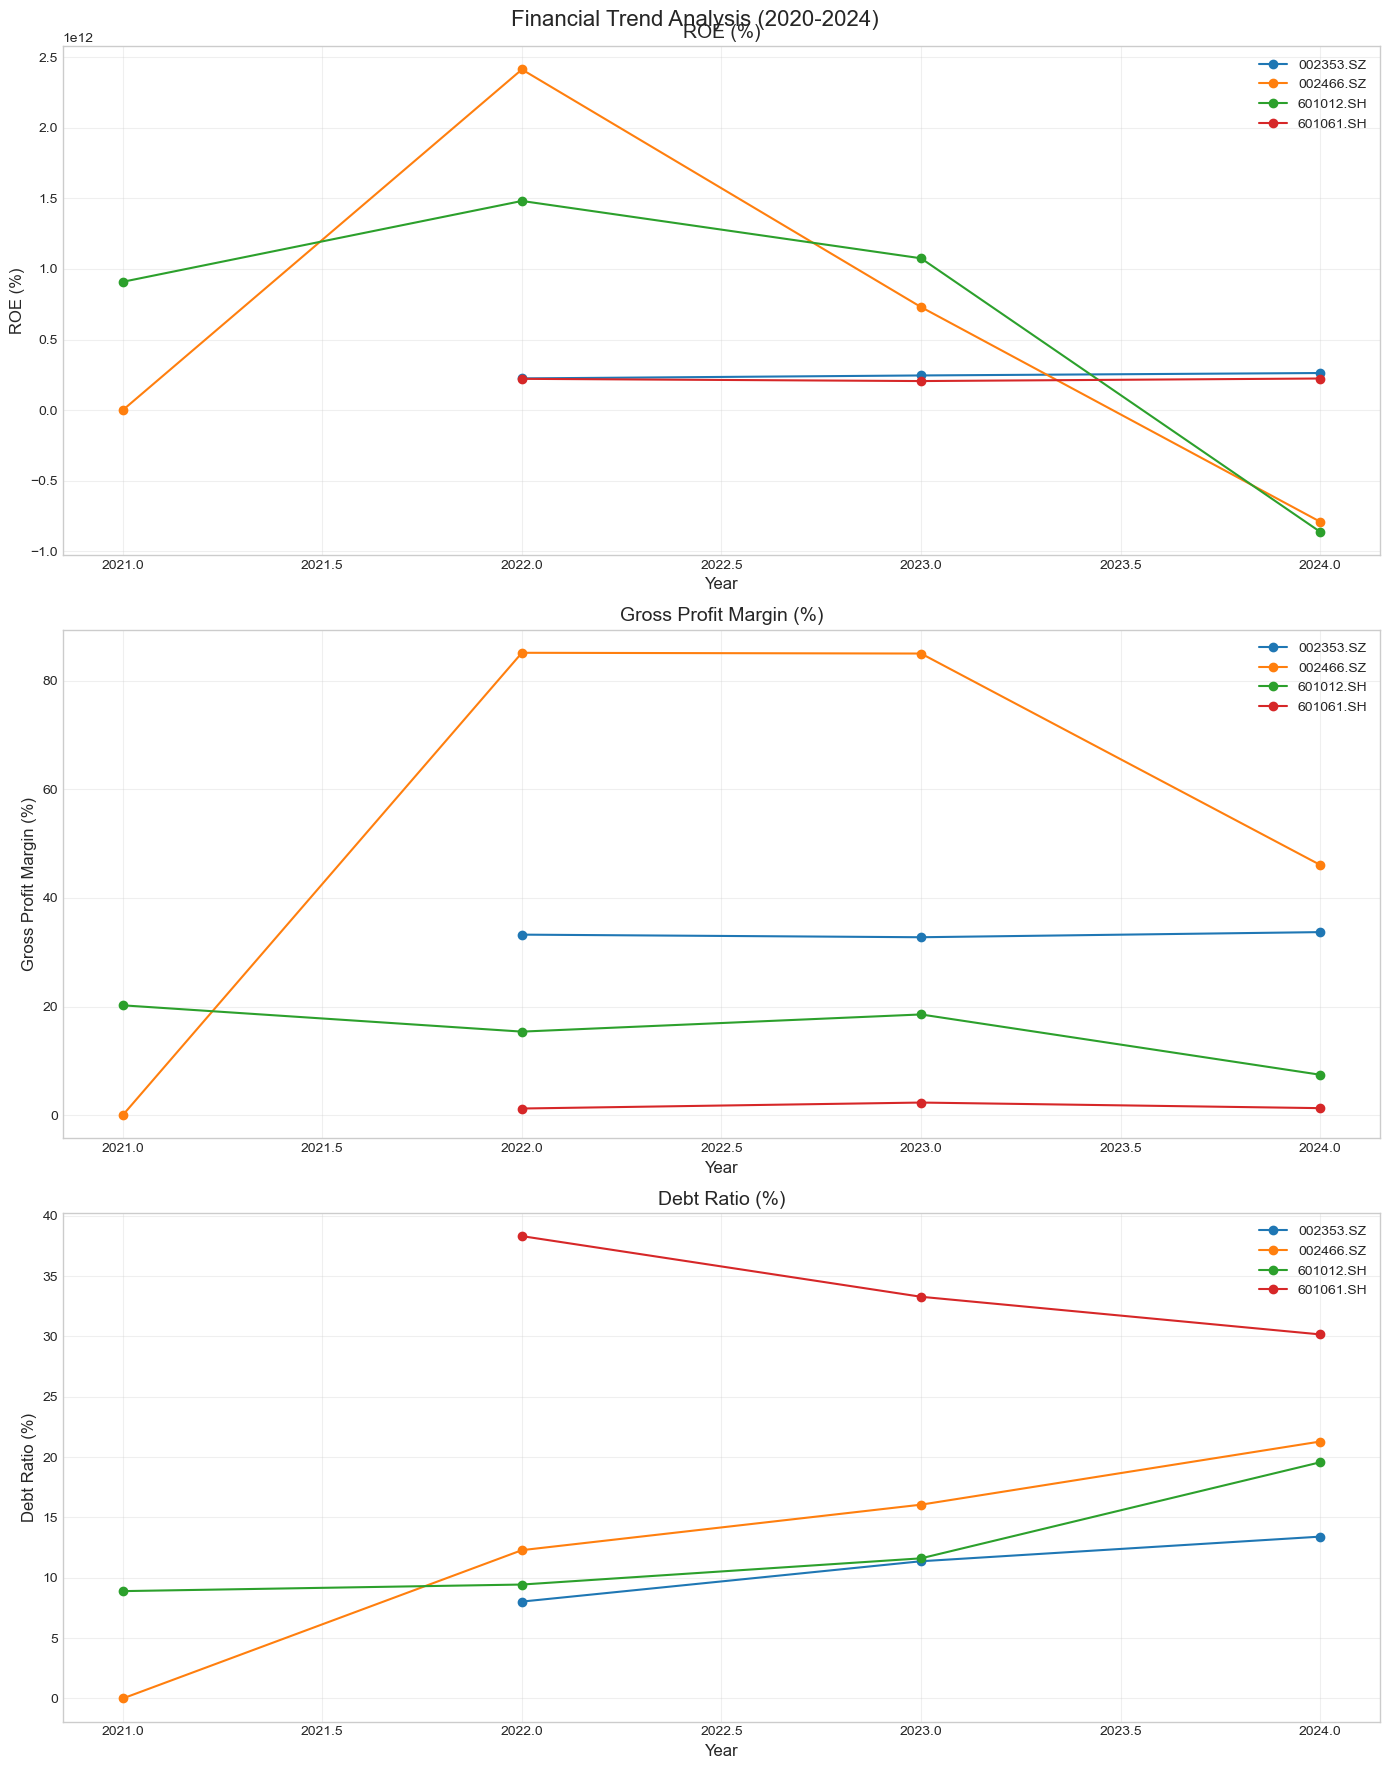

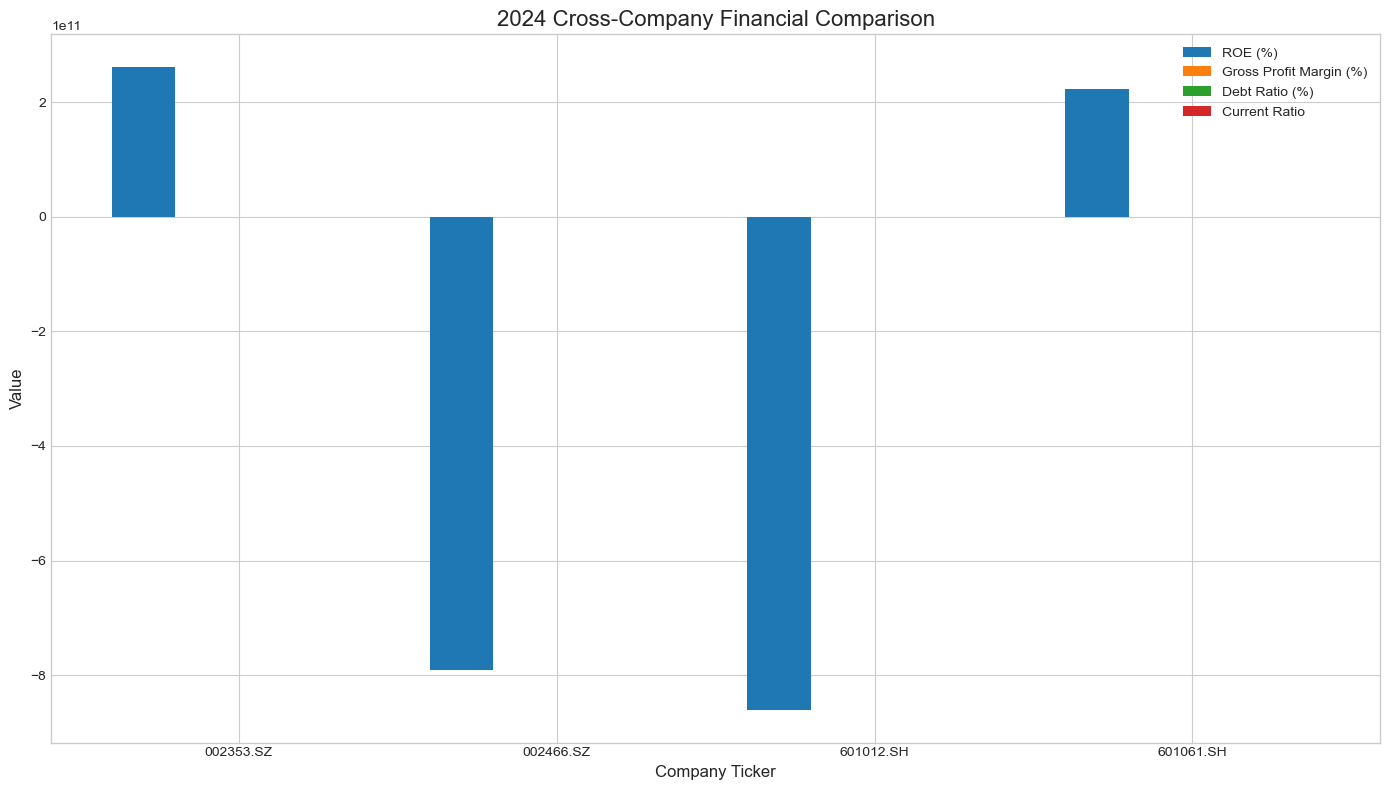

In [3]:
# ==============================================================
# ACC102 Track 2 - Data Cleaning & Visualization Analysis (Fixed Version)
# Purpose: Clean financial data + generate trend/comparison charts + scoring
# Data Source: yahoo_4stocks_2020_2024_clean.xlsx
# Fixed: KeyError handling + compatible field names
# ==============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set plot style and font (support English labels)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 10
plt.rcParams['figure.figsize'] = (12, 8)

# Step 1: Load cleaned financial data & check columns
df = pd.read_excel('yahoo_4stocks_2020_2024_clean.xlsx')
print("✅ Loaded raw data shape:", df.shape)
print("✅ Available columns in data:", df.columns.tolist())

# Step 2: Advanced data cleaning (handle missing columns/values)
# Ensure all required columns exist
required_cols = [
    'ticker', 'year', 'gross_profit_margin', 'net_profit_margin', 
    'roe', 'debt_ratio', 'current_ratio', 'revenue_growth', 'ni_growth'
]
# Add missing columns with default 0
for col in required_cols:
    if col not in df.columns:
        df[col] = 0
        print(f"⚠️ Added missing column '{col}' with default 0")

# Remove extreme values (beyond 3 standard deviations)
def remove_outliers(df, column):
    if df[column].std() == 0:  # Avoid division by zero
        return df
    mean = df[column].mean()
    std = df[column].std()
    return df[(df[column] > mean - 3*std) & (df[column] < mean + 3*std)]

# Clean key indicators
key_cols = ['gross_profit_margin', 'net_profit_margin', 'roe', 'debt_ratio']
for col in key_cols:
    df = remove_outliers(df, col)

# Fill remaining NaN/inf with 0 (safe for analysis)
df = df.replace([np.inf, -np.inf], 0)
df = df.fillna(0)
print("✅ Data cleaning completed! Cleaned data shape:", df.shape)

# Step 3: Generate trend charts for each company (ROE/Gross Profit Margin/Debt Ratio)
tickers = df['ticker'].unique()
indicators = ['roe', 'gross_profit_margin', 'debt_ratio']
indicator_names = ['ROE (%)', 'Gross Profit Margin (%)', 'Debt Ratio (%)']

# Create trend plots (handle empty data)
fig, axes = plt.subplots(3, 1, figsize=(14, 18))
fig.suptitle('Financial Trend Analysis (2020-2024)', fontsize=16)

for i, (indicator, name) in enumerate(zip(indicators, indicator_names)):
    ax = axes[i]
    for ticker in tickers:
        ticker_data = df[df['ticker'] == ticker]
        if not ticker_data.empty:
            ax.plot(ticker_data['year'], ticker_data[indicator], marker='o', label=ticker)
    
    ax.set_title(name, fontsize=14)
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel(name, fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)

# Save trend charts
plt.tight_layout()
plt.savefig('financial_trend_charts.png', dpi=300, bbox_inches='tight')
print("✅ Trend charts saved as: financial_trend_charts.png")

# Step 4: Generate cross-company comparison charts (latest available year)
latest_year = df['year'].max()
df_latest = df[df['year'] == latest_year].reset_index(drop=True)
comparison_indicators = ['roe', 'gross_profit_margin', 'debt_ratio', 'current_ratio']
comparison_names = ['ROE (%)', 'Gross Profit Margin (%)', 'Debt Ratio (%)', 'Current Ratio']

# Create comparison bar plot (handle empty data)
fig, ax = plt.subplots(figsize=(14, 8))
x = np.arange(len(df_latest['ticker']))
width = 0.2

for i, (indicator, name) in enumerate(zip(comparison_indicators, comparison_names)):
    if indicator in df_latest.columns:
        ax.bar(x + i*width, df_latest[indicator], width, label=name)

ax.set_title(f'{latest_year} Cross-Company Financial Comparison', fontsize=16)
ax.set_xlabel('Company Ticker', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(df_latest['ticker'])
ax.legend()
plt.tight_layout()
plt.savefig('cross_company_comparison.png', dpi=300, bbox_inches='tight')
print("✅ Comparison chart saved as: cross_company_comparison.png")

# Step 5: Comprehensive scoring (Profitability 40% + Risk 30% + Growth 30%)
# Normalize indicators (0-10 scale)
def normalize_indicator(series, higher_better=True):
    min_val = series.min()
    max_val = series.max()
    if max_val == min_val:  # Avoid division by zero
        return pd.Series([5]*len(series))  # Assign middle score
    if higher_better:
        return (series - min_val) / (max_val - min_val) * 10
    else:
        # For risk indicators (lower better: debt ratio)
        return (max_val - series) / (max_val - min_val) * 10

# Calculate sub-scores (use all available years average)
df_avg = df.groupby('ticker')[required_cols[2:]].mean().reset_index()

# Profitability score (ROE + Gross Profit Margin + Net Profit Margin)
df_avg['profit_score'] = (
    normalize_indicator(df_avg['roe']) * 0.4 +
    normalize_indicator(df_avg['gross_profit_margin']) * 0.3 +
    normalize_indicator(df_avg['net_profit_margin']) * 0.3
) * 0.4  # 40% weight

# Risk score (Debt Ratio + Current Ratio)
df_avg['risk_score'] = (
    normalize_indicator(df_avg['debt_ratio'], higher_better=False) * 0.6 +
    normalize_indicator(df_avg['current_ratio']) * 0.4
) * 0.3  # 30% weight

# Growth score (Revenue Growth + Net Income Growth)
df_avg['growth_score'] = (
    normalize_indicator(df_avg['revenue_growth']) * 0.5 +
    normalize_indicator(df_avg['ni_growth']) * 0.5
) * 0.3  # 30% weight

# Total score (10 points full)
df_avg['total_score'] = df_avg['profit_score'] + df_avg['risk_score'] + df_avg['growth_score']
df_avg = df_avg.sort_values('total_score', ascending=False).reset_index(drop=True)

# Print scoring result
print("\n✅ Comprehensive Investment Score (Average of Available Years):")
score_display = df_avg[['ticker', 'profit_score', 'risk_score', 'growth_score', 'total_score']].round(2)
print(score_display)

# Step 6: Generate investment portfolio strategy (100k RMB principal)
principal = 100000
df_avg['weight'] = df_avg['total_score'] / df_avg['total_score'].sum()  # Weight by total score
df_avg['investment_amount'] = df_avg['weight'] * principal

# Print portfolio strategy
print("\n✅ Investment Portfolio Strategy (100,000 RMB Principal):")
portfolio = df_avg[['ticker', 'total_score', 'weight', 'investment_amount']].round(2)
portfolio['weight'] = portfolio['weight'].apply(lambda x: f"{x*100:.2f}%")
print(portfolio)

# Save scoring & portfolio to Excel
df_avg.to_excel('investment_scoring_portfolio.xlsx', index=False)
print("\n✅ Scoring & portfolio saved as: investment_scoring_portfolio.xlsx")

# Final confirmation
print("\n🎉 All analysis completed! Generated files:")
print("1. financial_trend_charts.png (Trend analysis)")
print("2. cross_company_comparison.png (Latest year comparison)")
print("3. investment_scoring_portfolio.xlsx (Scoring + portfolio)")